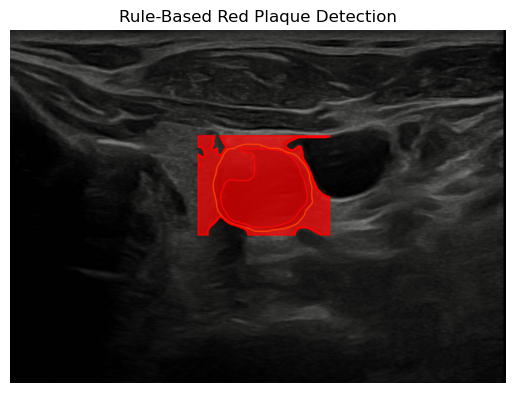

------------------------------
PLAQUE TEXTURE ANALYSIS
------------------------------
Contrast (Roughness):    316.37
Homogeneity (Smoothness): 0.40
Energy (Uniformity):      0.16
Correlation:              0.96
Clinical Suggestion:      Heterogeneous (Potential Calcification/Vulnerability)
------------------------------


In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Image Loading & Prep
# -----------------------------
img = cv2.imread("test3.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
denoised = cv2.bilateralFilter(gray, 9, 75, 75)
enhanced = cv2.createCLAHE(clipLimit=3.0).apply(denoised)

# -----------------------------
# 2. Artery ROI Selection
# -----------------------------
roi = cv2.selectROI("Select Artery Region", enhanced, False)
cv2.destroyAllWindows()
x, y, w, h = roi
roi_img = enhanced[y:y+h, x:x+w]
roi_color = img[y:y+h, x:x+w].copy()

# -----------------------------
# 3. STATISTICAL RULE-BASED DETECTION
# -----------------------------
blur = cv2.GaussianBlur(roi_img, (5, 5), 0)
_, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

best_plaque_cnt = None
max_rule_score = -1

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 100: continue # Rule: Ignore tiny noise

    # Measure 1: Solidity (How much of the 'blob' is filled?)
    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    solidity = float(area) / hull_area if hull_area > 0 else 0

    # Measure 2: Mean Intensity (Plaque is bright/hyperechoic)
    mask = np.zeros(roi_img.shape, np.uint8)
    cv2.drawContours(mask, [cnt], -1, 255, -1)
    mean_val = cv2.mean(roi_img, mask=mask)[0]

    # Measure 3: Centricity (Plaque is usually attached to the wall near center)
    M = cv2.moments(cnt)
    cX = int(M["m10"] / M["m00"]) if M["m00"] != 0 else 0
    # Higher score if it's closer to the center-left (where your reference was)
    dist_score = 1.0 / (1.0 + abs(cX - (w * 0.3))) 

    # --- THE RULE ---
    # Combine Brightness + Solidity + Position
    rule_score = mean_val * solidity * dist_score

    if rule_score > max_rule_score:
        max_rule_score = rule_score
        best_plaque_cnt = cnt

# -----------------------------
# 4. Final Output: BRIGHT RED BLOB
# -----------------------------
if best_plaque_cnt is not None:
    # Create the solid red highlight you asked for
    overlay = roi_color.copy()
    cv2.drawContours(overlay, [best_plaque_cnt], -1, (0, 0, 255), -1)
    
    # 70% opacity for the bright red look
    cv2.addWeighted(overlay, 0.7, roi_color, 0.3, 0, roi_color)
    
    # Draw a clean red border
    cv2.drawContours(roi_color, [best_plaque_cnt], -1, (0, 0, 255), 2)
    
    # Put it back in the main image
    img[y:y+h, x:x+w] = roi_color

# Display
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Rule-Based Red Plaque Detection")
plt.axis("off")
plt.show()

from skimage.feature import graycomatrix, graycoprops

# -----------------------------
# 5. TEXTURE ANALYSIS (GLCM)
# -----------------------------
if best_plaque_cnt is not None:
    # Create a mask for just the plaque
    plaque_mask = np.zeros(roi_img.shape, dtype=np.uint8)
    cv2.drawContours(plaque_mask, [best_plaque_cnt], -1, 255, -1)
    
    # Extract the pixel values belonging to the plaque
    # We use the 'enhanced' ROI image for better texture contrast
    plaque_pixels = cv2.bitwise_and(roi_img, roi_img, mask=plaque_mask)
    
    # GLCM requires integer values. We calculate it for 4 directions 
    # (0, 45, 90, 135 degrees) to ensure rotation invariance.
    distances = [1, 2] # Look at immediate and near neighbors
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    
    glcm = graycomatrix(plaque_pixels, 
                        distances=distances, 
                        angles=angles, 
                        levels=256, 
                        symmetric=True, 
                        normed=True)

    # Calculate specific texture properties
    contrast = graycoprops(glcm, 'contrast').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()
    energy = graycoprops(glcm, 'energy').mean()
    correlation = graycoprops(glcm, 'correlation').mean()

    # -----------------------------
    # 6. REPORTING RESULTS
    # -----------------------------
    print("-" * 30)
    print("PLAQUE TEXTURE ANALYSIS")
    print("-" * 30)
    print(f"Contrast (Roughness):    {contrast:.2f}")
    print(f"Homogeneity (Smoothness): {homogeneity:.2f}")
    print(f"Energy (Uniformity):      {energy:.2f}")
    print(f"Correlation:              {correlation:.2f}")
    
    # Simple Interpretation
    if contrast > 50: # Threshold varies by image quality
        status = "Heterogeneous (Potential Calcification/Vulnerability)"
    else:
        status = "Homogeneous (Stable Plaque)"
    print(f"Clinical Suggestion:      {status}")
    print("-" * 30)